# Unsupervised exploration (_Mushroom_)

In [ ]:
from experiments.utils.constants import RANDOM_SEED
VERBOSE = True
DATASET_NAME = "Mushroom"
DATASET_ID = 73

## Dataset

In [ ]:
# fetch dataset
from ucimlrepo import fetch_ucirepo
dataset = fetch_ucirepo(id=DATASET_ID)
X = dataset.data.features.values
y = dataset.data.targets.values.ravel()
print(f"Dataset shape: {X.shape}, {y.shape}")

In [10]:
# encode data
import pandas as pd
X = pd.get_dummies(pd.DataFrame(X), dummy_na=True).values

In [11]:
# scale data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
del X

## Modeling

In [12]:
from minisom_representation import calc_som_hyparams, SomRepresentation, plot_som_convergence_over_epochs

In [13]:
# use helper methods to get SOM hyperparameter recommendations
print("Recommended SOM parameters:", calc_som_hyparams(X_scaled))
print("Recommended SOM parameters:", calc_som_hyparams(X_scaled, initial_sigma_factor=3.0))

Recommended SOM parameters: {'d1': 21, 'd2': 22, 'sigma': 11.0}
Recommended SOM parameters: {'d1': 21, 'd2': 22, 'sigma': 7.33}


In [14]:
# define actual hyperparameters
recommended_params = calc_som_hyparams(X_scaled, initial_sigma_factor=3.0)
d1, d2 = recommended_params.get("d1"), recommended_params.get("d2")
sigma = recommended_params.get("sigma")
print("d1 x d2:", d1, "x", d2)
print("sigma:", sigma)
decay_function = "linear_decay_to_zero"
fit_type = "online"
epoch = None

d1 x d2: 21 x 22
sigma: 7.33


Evaluating for epochs of [ 1  2 12 22 32 42]...
Training SOM for 1 epochs...
Training SOM for 2 epochs...
Training SOM for 12 epochs...
Training SOM for 22 epochs...
Training SOM for 32 epochs...
Training SOM for 42 epochs...


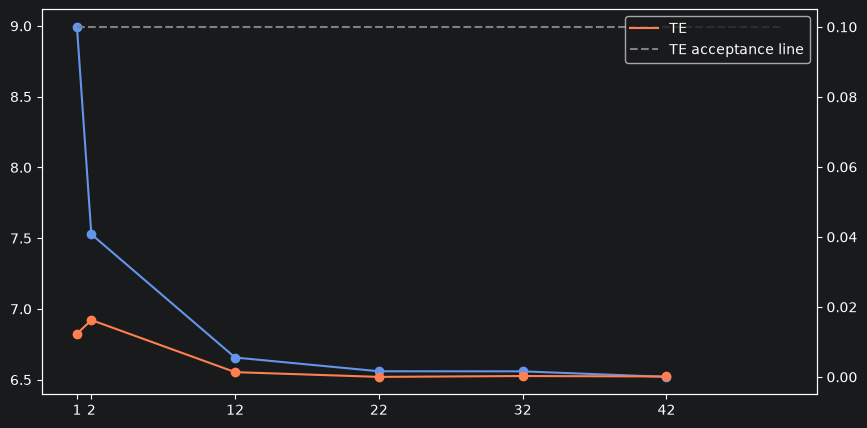


QE (first -> last): 	 8.99 -> 6.52
TE (first -> last): 	 0.01 -> 0.00


In [16]:
# test candidate values for `num_iteration` hyperparameter
fig, errors_qe, errors_te = plot_som_convergence_over_epochs(
    SomRepresentation(d1=d1, d2=d2, sigma=sigma, random_seed=RANDOM_SEED, verbose=False, decay_function=decay_function),
    X_scaled,
    fit_type=fit_type, te_ceiling=.1,
    epoch_step_from=2, epoch_step_to=50, epoch_step=10,
    figsize=(10, 5), show_fig=True, verbose=VERBOSE
)
print(f"\nQE (first -> last): \t {errors_qe[0]:.2f} -> {errors_qe[-1]:.2f}")
print(f"TE (first -> last): \t {errors_te[0]:.2f} -> {errors_te[-1]:.2f}")

In [19]:
# set selected `num_iteration` as epoch
epoch = 40

In [20]:
# fit SOM representation
som_rep = SomRepresentation(d1=d1, d2=d2, sigma=sigma, random_seed=RANDOM_SEED, verbose=VERBOSE, decay_function=decay_function) \
    .fit_online(X_scaled, num_iteration=epoch)

 [ 324960 / 324960 ] 100% - 0:00:00 left 
 quantization error: 6.546332874572373

 An SOM representation has been fitted as follows:
------------------------------------------------------- 

Fit strategy: online 

Hyperparameters of SOM: 

{'input_len': 138, 'x': 21, 'y': 22, 'sigma': 7.33, 'topology': 'rectangular', 'learning_rate': 0.5, 'decay_function': 'linear_decay_to_zero', 'sigma_decay_function': 'asymptotic_decay', 'neighborhood_function': 'gaussian', 'activation_distance': 'euclidean', 'random_seed': 42, 'num_iteration': 40, 'use_epochs': True, 'random_order': True, 'verbose': True} 

Quality of SOM: 

Quantization Error (QE):	6.546332874572373
Topographic Error (TE): 	0.00012309207287050715


## Inspection of the learned 2D topology

In [21]:
# create Basin
from lilypond import Basin
basin = Basin.from_som_representation(som_rep, random_seed=RANDOM_SEED, verbose=VERBOSE)

In [22]:
# traditional visuals
basin.legacy_pond().visualize_distance_map();
basin.legacy_pond().visualize_activation_map();

In [ ]:
# lilypond visuals
basin.pond() \
    .rhizome_layer() \
    .pad_layer(gap="nogap") \
    .petal_layer(min_size=8, max_size=25) \
    .visualize(width=1000, height=800);

## Register representation model in Databricks

In [28]:
from dotenv import load_dotenv
load_dotenv()

True

In [29]:
CATALOG = "workspace"
SCHEMA = "lilypond_experiments"
MODEL_NAME = "som-mushroom"
MODEL_PATH = f"{CATALOG}.{SCHEMA}.{MODEL_NAME}"
MODEL_PATH

'workspace.lilypond_experiments.som-mushroom'

In [30]:
import mlflow
import pandas as pd
from typing import Any

EXPERIMENT_NAME = "/Users/matebalogh@ophelia-rnd.dev/Bianor_LilypondExperiments_Mushroom"
mlflow.set_experiment(experiment_name=EXPERIMENT_NAME)

class MLflowSomModelWrapper(mlflow.pyfunc.PythonModel):
    def __init__(self, model:SomRepresentation, scaler):
        self.model = model
        self.scaler = scaler
    def predict(self, context, model_input, params: dict[str, Any] | None = None):
        """First transforms the input data via scaler, then predicts the winner node of the SOM."""
        return [self.model.som.winner(x) for x in self.scaler.transform(model_input.to_numpy())]

with mlflow.start_run():
    model = MLflowSomModelWrapper(som_rep, scaler)

    mlflow.log_metric("QE", som_rep.quantization_error)
    mlflow.log_metric("TE", som_rep.topographic_error)

    mlflow.pyfunc.log_model(
        python_model=model,
        name=MODEL_NAME,
        input_example=pd.DataFrame(X_scaled[:3]),
        pip_requirements=[
            "numpy",
            "pandas",
            "scikit-learn==1.5.2",
            "mlflow",
            "minisom",
        ],
        registered_model_name=MODEL_PATH
    )

2026/09/03 00:09:44 INFO mlflow.tracking.fluent: Experiment with name '/Users/matebalogh@ophelia-rnd.dev/Bianor_LilypondExperiments_Mushroom' does not exist. Creating a new experiment.
If you are using MLflow Tracing, consider storing your traces in Unity Catalog for unlimited storage (no 100,000 trace limit), fine-grained access controls, and queryability from notebooks, SQL, and dashboards. Learn more: https://docs.databricks.com/aws/en/mlflow3/genai/tracing/trace-unity-catalog
/opt/homebrew/Caskroom/miniconda/base/envs/wsom-lilypond-exp/lib/python3.11/site-packages/mlflow/pyfunc/utils/data_validation.py:187: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(
2026/09/03 00:09:54 WARNING mlflow.pyfunc: Passing a Python object as `python_model` causes it to be serialized using Cl

🏃 View run ambitious-calf-614 at: dbc-ca44ccd5-3843.cloud.databricks.com/ml/experiments/1916796335158891/runs/bdcc34db49624975bcceed9a840d21bc
🧪 View experiment at: dbc-ca44ccd5-3843.cloud.databricks.com/ml/experiments/1916796335158891


In [31]:
version = 1
registered_model = f"{MODEL_NAME}/{version}"
registered_model

'som-mushroom/1'

## Register metadata in Bianor

In [32]:
from databricks.connect import DatabricksSession
spark = DatabricksSession.builder.getOrCreate()

In [33]:
from bianor_databricks_kit import BianorRecordManager
bianor_recorder = BianorRecordManager(catalog=CATALOG, schema=SCHEMA, spark=spark)

In [34]:
registered_model_location = f"{CATALOG}.{SCHEMA}.{registered_model}"
registered_model_location

'workspace.lilypond_experiments.som-mushroom/1'

In [35]:
bianor_recorder.new_representation(name=f"{DATASET_NAME} Representation", som_model_location=registered_model_location, features_location="c.s.t") # FIXME